In [1]:
# ── Jupyter Notebook matplotlib 한글 폰트 설정 (macOS) ──────────────────────
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 기본 한글 폰트: AppleGothic
plt.rcParams['font.family']       = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 설정 확인
print(f"현재 폰트: {plt.rcParams['font.family']}")

현재 폰트: ['AppleGothic']


In [2]:
"""
SafeFam — SMS 피싱 탐지 베이즈 분류기 학습 파이프라인 v2
==========================================================
v2 변경사항:
  - CalibratedClassifierCV(method='isotonic') 추가
    → ComplementNB 확률이 0/1 양극단으로 몰리는 문제 해결
    → risk_score가 0~100 구간에 고르게 분산되어 상/중/하 의미있는 구분 가능

탐지 파이프라인 내 위치:
  URL 있음  → 베이즈(텍스트) + VirusTotal(URL) 병렬 → 종합 risk_score (Spring Boot 조율)
  URL 없음  → 베이즈 단독 risk_score
  MEDIUM    → Claude API 에스컬레이션 (40~69점 구간)
"""

from __future__ import annotations

import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack
from sklearn.calibration import CalibratedClassifierCV   # ← v2 추가
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.naive_bayes import ComplementNB

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# 상수
# ─────────────────────────────────────────────────────────────────────────────

DATA_PATH       = Path("../Data/SMSData/phishing_total_dataset_2705.csv")
MODEL_PATH      = Path("phishing_model_artifact.pkl")
VECTORIZER_PATH = Path("phishing_vectorizer.pkl")

RANDOM_STATE           = 42
VAL_SIZE               = 0.15   # 튜닝(alpha/threshold) 전용
TEST_SIZE              = 0.15   # 최종 평가 전용 — 튜닝에 절대 사용하지 않음
TARGET_PHISHING_RECALL = 0.85

# risk_level 구간 — 종합 점수(베이즈 + VirusTotal)에도 동일하게 적용
RISK_HIGH_THRESHOLD   = 70   # HIGH   : 70점 이상
RISK_MEDIUM_THRESHOLD = 40   # MEDIUM : 40~69점 (LLM 에스컬레이션 대상)
                              # LOW    : 40점 미만

# 격자 탐색 범위
ALPHA_GRID     = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
THRESHOLD_GRID = np.round(np.arange(0.30, 0.75, 0.05), 2)


# ─────────────────────────────────────────────────────────────────────────────
# 정규화 패턴
# URL/전화번호/계좌번호(6자리+)/금액만 토큰화.
# 날짜·수량 등 일반 숫자 유지 — 전체 치환 시 정규화 후 중복 폭증 확인(1797건).
# ─────────────────────────────────────────────────────────────────────────────

_RE_URL      = re.compile(
    r"https?://\S+|[a-zA-Z0-9.-]+\.(kr|com|net|cyou|xyz|me|io|cc)\S*"
)
_RE_PHONE    = re.compile(r"\d{2,4}-\d{3,4}-\d{4}")
_RE_LONG_NUM = re.compile(r"\b\d{6,}\b")
_RE_AMOUNT   = re.compile(r"\d+[,\d]*원")

# has_short_url: phishing 27.8% vs normal 0.4% — 가장 강한 단독 신호
_RE_SHORT_URL = re.compile(
    r"bit\.ly|goo\.gl|tinyurl|gourl|ow\.ly|n\.bnuee|han\.gl|cutt\.ly"
)
_RE_WEB_TAG  = re.compile(r"\[Web발신\]|\[국외발신\]|\[국제발신\]")


# ─────────────────────────────────────────────────────────────────────────────
# 전처리
# ─────────────────────────────────────────────────────────────────────────────

def _normalize_text(text: str) -> str:
    """가변 식별값을 일반화 토큰으로 치환. 모델이 구조적 패턴을 학습하도록 유도."""
    text = _RE_URL.sub("<URL>", text)
    text = _RE_PHONE.sub("<전화번호>", text)
    text = _RE_LONG_NUM.sub("<긴숫자>", text)
    text = _RE_AMOUNT.sub("<금액>", text)
    return text.strip()


def _extract_struct_features(texts: pd.Series, has_url: pd.Series) -> np.ndarray:
    """
    텍스트 n-gram으로 포착하기 어려운 구조적 신호 6개를 boolean 피처로 추출.
    반환 shape: (n_samples, 6)
    """
    return np.column_stack([
        has_url.astype(int).values,                                         # 0: URL 포함
        texts.str.contains(_RE_SHORT_URL).astype(int).values,               # 1: 단축URL (강신호)
        texts.str.contains(_RE_PHONE).astype(int).values,                   # 2: 전화번호
        texts.str.contains(_RE_AMOUNT).astype(int).values,                  # 3: 금액
        texts.str.contains(_RE_WEB_TAG).astype(int).values,                 # 4: 통신사태그(역방향)
        (texts.str.len() > 100).astype(int).values,                         # 5: 100자 초과
    ])


# ─────────────────────────────────────────────────────────────────────────────
# 데이터 로드
# ─────────────────────────────────────────────────────────────────────────────

def load_data(path: Path) -> pd.DataFrame:
    """
    CSV 로드 → 무결성 검증 → 정규화 → text_norm 기준 중복 제거.

    중복 제거 기준: text_norm (정규화 후 동일 패턴)
    - URL/금액만 다른 동일 템플릿을 하나로 취급
    - 미제거 시 train/test 데이터 누수 발생 (2705 → 811건)
    """
    df = pd.read_csv(path)

    required_cols = {"text", "label", "type", "has_url"}
    if missing := required_cols - set(df.columns):
        raise ValueError(f"누락 컬럼: {missing}")
    if df.isnull().any().any():
        raise ValueError("결측치가 존재합니다.")
    if not {"phishing", "normal"}.issuperset(set(df["label"].unique())):
        raise ValueError(f"예상치 못한 label 값: {df['label'].unique()}")

    print(f"[Load] 원본 {len(df)}건 | {df['label'].value_counts().to_dict()}")

    df["text_norm"] = df["text"].apply(_normalize_text)

    before = len(df)
    df = df.drop_duplicates(subset="text_norm").reset_index(drop=True)
    print(
        f"[Dedup] text_norm 기준 중복 제거: {before} → {len(df)}건 | "
        f"{df['label'].value_counts().to_dict()}"
    )
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Train / Test 분리
# ─────────────────────────────────────────────────────────────────────────────

def split_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    StratifiedShuffleSplit 2단계: label 비율 유지하며 train/val/test 분리.

    1단계) 전체 → (train+val) / test
    2단계) (train+val) → train / val  (val 비율을 전체 기준 VAL_SIZE로 재조정)

    val: 하이퍼파라미터(alpha/threshold) 튜닝 전용
    test: 최종 평가 1회 전용 — 튜닝에 재사용하면 지표가 낙관적으로 부풀려짐(test set 누수)
    """
    sss_test = StratifiedShuffleSplit(
        n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    trainval_idx, test_idx = next(sss_test.split(df, df["label"]))
    df_trainval = df.iloc[trainval_idx].reset_index(drop=True)
    df_test     = df.iloc[test_idx].reset_index(drop=True)

    val_ratio = VAL_SIZE / (1 - TEST_SIZE)  # trainval 내 비중으로 재조정
    sss_val = StratifiedShuffleSplit(
        n_splits=1, test_size=val_ratio, random_state=RANDOM_STATE
    )
    train_idx, val_idx = next(sss_val.split(df_trainval, df_trainval["label"]))
    df_train = df_trainval.iloc[train_idx].reset_index(drop=True)
    df_val   = df_trainval.iloc[val_idx].reset_index(drop=True)

    def _fmt(d: pd.DataFrame) -> str:
        vc = d["label"].value_counts()
        return (
            f"phishing={vc.get('phishing', 0)} ({vc.get('phishing', 0)/len(d):.1%}) | "
            f"normal={vc.get('normal', 0)} ({vc.get('normal', 0)/len(d):.1%})"
        )

    print(f"[Split] Train {len(df_train)}건: {_fmt(df_train)}")
    print(f"[Split] Val   {len(df_val)}건:  {_fmt(df_val)}")
    print(f"[Split] Test  {len(df_test)}건:  {_fmt(df_test)}")
    return df_train, df_val, df_test


# ─────────────────────────────────────────────────────────────────────────────
# 벡터화
# ─────────────────────────────────────────────────────────────────────────────

def build_vectorizer() -> CountVectorizer:
    """char_wb(단어 경계 문자 n-gram): 형태소 분석기 없이 한글 조사 변형 대응."""
    return CountVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 4),
        min_df=2,
        max_df=0.95,
        max_features=8_000,
    )


def build_feature_matrix(
    vectorizer: CountVectorizer,
    text_norm: pd.Series,
    struct: np.ndarray,
    *,
    fit: bool,
):
    """
    텍스트 피처(CountVectorizer) + 구조적 피처(6개) sparse hstack 결합.
    fit=True: fit_transform (학습 전용), fit=False: transform only (누수 방지)
    """
    X_text   = vectorizer.fit_transform(text_norm) if fit else vectorizer.transform(text_norm)
    X_struct = csr_matrix(struct)
    return hstack([X_text, X_struct])


# ─────────────────────────────────────────────────────────────────────────────
# 학습 및 튜닝
# ─────────────────────────────────────────────────────────────────────────────

def _phishing_idx(model) -> int:
    """model.classes_ 에서 'phishing' 인덱스 반환."""
    return list(model.classes_).index("phishing")


def _compute_recalls(model, X_test, y_test: pd.Series, threshold: float) -> tuple[float, float]:
    """threshold 적용 후 Recall(phishing), Recall(normal) 반환."""
    y_prob = model.predict_proba(X_test)[:, _phishing_idx(model)]
    y_pred = np.where(y_prob >= threshold, "phishing", "normal")
    cm     = confusion_matrix(y_test, y_pred, labels=["normal", "phishing"])

    rec_p = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else 0.0
    rec_n = cm[0, 0] / cm[0].sum() if cm[0].sum() > 0 else 0.0
    return rec_p, rec_n


def train_and_tune(
    X_train, y_train: pd.Series,
    X_val,   y_val:   pd.Series,
    vec_type: str = "char_ngram",
) -> dict:
    """
    [격자 탐색] alpha × threshold 전체 탐색.
    튜닝 기준: validation 세트 사용 (test는 최종 평가 전용으로 봉인 — test set 누수 방지)

    v2 변경: ComplementNB를 CalibratedClassifierCV(isotonic)로 감쌈.
    - isotonic: 비선형 보정 — 작은 데이터셋에서 sigmoid보다 안정적
    - cv=5: 5-fold 교차검증으로 보정 파라미터 추정
    - 보정 후 prob_phishing이 0~1 사이에 고르게 분산 → 상/중/하 구분 가능

    선택 기준:
      1순위) Recall(phishing) >= TARGET 조건 하 Recall(normal) 최대
      2순위) 목표 미달 시 Recall(phishing) 최대 (fallback)

    Args:
        vec_type: 현재 탐색 중인 벡터화 방식 이름 (로그 출력용, Voice 모델과 출력 형식 통일)

    Returns:
        dict: model, model_name, alpha, threshold, recall_phishing, recall_normal
    """
    best: dict = {
        "model": None, "model_name": "", "alpha": None,
        "threshold": None, "recall_phishing": 0.0, "recall_normal": 0.0,
    }

    header = (
        f"{'모델':>15} | {'alpha':>5} | {'thresh':>6} "
        f"| {'rec_phish':>10} | {'rec_normal':>10}"
    )
    print(f"\n{'='*64}")
    print(f"[ 격자 탐색 — {vec_type} ]")
    print(f"{'='*64}")
    print(header)
    print("-" * len(header))

    for alpha in ALPHA_GRID:
        # CalibratedClassifierCV: ComplementNB 위에 isotonic 보정 레이어 적용
        # → predict_proba()가 실제 비율에 맞는 교정된 확률 반환
        base_model = ComplementNB(alpha=alpha)
        calibrated = CalibratedClassifierCV(
            estimator=base_model,
            method="isotonic",   # 비선형 보정 (sigmoid보다 작은 데이터셋에 안정적)
            cv=5,                # 5-fold로 보정 파라미터 추정
        )
        calibrated.fit(X_train, y_train)

        for threshold in THRESHOLD_GRID:
            rec_p, rec_n = _compute_recalls(calibrated, X_val, y_val, threshold)

            print(
                f"{'ComplementNB':>15} | {alpha:>5} | {threshold:>6.2f} "
                f"| {rec_p:>10.4f} | {rec_n:>10.4f}"
            )

            if rec_p >= TARGET_PHISHING_RECALL and rec_n > best["recall_normal"]:
                best.update({
                    "model": calibrated, "model_name": "ComplementNB",
                    "alpha": alpha, "threshold": threshold,
                    "recall_phishing": rec_p, "recall_normal": rec_n,
                })
            elif best["model"] is None and rec_p > best["recall_phishing"]:
                best.update({
                    "model": calibrated, "model_name": "ComplementNB",
                    "alpha": alpha, "threshold": threshold,
                    "recall_phishing": rec_p, "recall_normal": rec_n,
                })

    return best


# ─────────────────────────────────────────────────────────────────────────────
# 벡터화 후보 비교 (Voice 모델과 동일 구조 — SMS는 char_ngram 단일 후보)
# ─────────────────────────────────────────────────────────────────────────────

VECTORIZER_CANDIDATES: dict[str, CountVectorizer] = {
    "char_ngram": build_vectorizer(),
}


def compare_vectorizers(
    df_train: pd.DataFrame,
    df_val:   pd.DataFrame,
) -> tuple[str, CountVectorizer, dict]:
    """
    벡터화 후보를 각각 격자 탐색하고 validation Recall(phishing) 기준 최적 조합을 반환.
    SMS는 char_ngram 단일 후보지만, Voice 모델(char/word 비교)과 출력 형식을 통일하기 위해
    동일한 비교 구조를 유지.

    Returns:
        (best_vec_type, best_vectorizer, best_result_dict)
    """
    struct_train = _extract_struct_features(df_train["text"], df_train["has_url"])
    struct_val   = _extract_struct_features(df_val["text"],   df_val["has_url"])

    comparison: dict[str, dict] = {}

    for vec_type, vectorizer in VECTORIZER_CANDIDATES.items():
        # train에만 fit — val은 transform only (데이터 누수 방지)
        X_train = build_feature_matrix(
            vectorizer, df_train["text_norm"], struct_train, fit=True
        )
        X_val = build_feature_matrix(
            vectorizer, df_val["text_norm"], struct_val, fit=False
        )

        result = train_and_tune(
            X_train, df_train["label"],
            X_val,   df_val["label"],
            vec_type,
        )
        result["vectorizer"]      = vectorizer
        result["vectorizer_type"] = vec_type
        comparison[vec_type]      = result

    # 비교 요약 출력
    print(f"\n{'='*64}")
    print("[ 벡터화 방식 비교 요약 ]")
    print(f"{'='*64}")
    print(f"{'방식':>12} | {'모델':>15} | {'alpha':>5} | {'thresh':>6} | {'rec_phish':>10} | {'rec_normal':>10}")
    print("-" * 70)
    for vec_type, result in comparison.items():
        if result["model"] is not None:
            print(
                f"{vec_type:>12} | {result['model_name']:>15} | "
                f"{result['alpha']:>5} | {result['threshold']:>6.2f} | "
                f"{result['recall_phishing']:>10.4f} | {result['recall_normal']:>10.4f}"
            )

    # Recall(phishing) >= TARGET 조건 하 Recall(normal) 최대인 벡터화 선택
    valid = {
        k: v for k, v in comparison.items()
        if v["model"] is not None and v["recall_phishing"] >= TARGET_PHISHING_RECALL
    }

    if valid:
        best_type   = max(valid, key=lambda k: valid[k]["recall_normal"])
    else:
        # 목표 미달 시 Recall(phishing) 최대
        best_type   = max(
            comparison,
            key=lambda k: comparison[k]["recall_phishing"] if comparison[k]["model"] else 0
        )
        print("[WARNING] 어떤 조합도 Recall(phishing) 목표를 달성하지 못했습니다.")

    best_result = comparison[best_type]
    print(f"\n★ 최적 벡터화: {best_type}")
    print(
        f"  모델={best_result['model_name']} | alpha={best_result['alpha']} "
        f"| threshold={best_result['threshold']}"
    )
    print(
        f"  Recall(phishing)={best_result['recall_phishing']:.4f} | "
        f"Recall(normal)={best_result['recall_normal']:.4f}"
    )

    return best_type, best_result["vectorizer"], best_result


# ─────────────────────────────────────────────────────────────────────────────
# 보정 후 확률 분포 검증
# ─────────────────────────────────────────────────────────────────────────────

def verify_probability_distribution(model, X_test, y_test: pd.Series) -> None:
    """
    보정 후 prob_phishing 분포를 확인.
    MEDIUM 구간(0.40~0.70)에 충분한 샘플이 있는지 검증.
    """
    probs = model.predict_proba(X_test)[:, _phishing_idx(model)]
    df_prob = pd.DataFrame({"prob": probs, "label": y_test.values})

    low    = (probs < 0.40).sum()
    medium = ((probs >= 0.40) & (probs < 0.70)).sum()
    high   = (probs >= 0.70).sum()

    print(f"\n{'='*64}\n[ 보정 후 prob_phishing 분포 검증 ]\n{'='*64}")
    print(f"LOW    (<0.40) : {low:>4}건 ({low/len(probs):.1%})")
    print(f"MEDIUM (0.40~0.70): {medium:>4}건 ({medium/len(probs):.1%})")
    print(f"HIGH   (≥0.70) : {high:>4}건 ({high/len(probs):.1%})")
    print(f"\nlabel별 평균 prob_phishing:")
    print(df_prob.groupby("label")["prob"].describe().round(4))

    if medium == 0:
        print("[WARNING] MEDIUM 구간 샘플 없음 — 보정 방식 재검토 필요")


# ─────────────────────────────────────────────────────────────────────────────
# 최종 평가
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(model, threshold: float, X_test, y_test: pd.Series) -> None:
    """최적 threshold 적용 후 classification report + confusion matrix 출력."""
    y_prob = model.predict_proba(X_test)[:, _phishing_idx(model)]
    y_pred = np.where(y_prob >= threshold, "phishing", "normal")

    print(f"\n{'='*64}")
    print(f"[ 최종 평가 (test 세트) — threshold={threshold} ]")
    print(f"{'='*64}")
    print(classification_report(y_test, y_pred, target_names=["normal", "phishing"]))

    cm = confusion_matrix(y_test, y_pred, labels=["normal", "phishing"])
    print(pd.DataFrame(
        cm,
        index=["실제 normal", "실제 phishing"],
        columns=["예측 normal", "예측 phishing"],
    ))

    rec_p = cm[1, 1] / cm[1].sum()
    rec_n = cm[0, 0] / cm[0].sum()
    print(f"\n★ Recall(phishing): {rec_p:.4f}  |  Recall(normal): {rec_n:.4f}")

    if rec_p < TARGET_PHISHING_RECALL:
        print(
            f"[WARNING] Recall(phishing) {rec_p:.4f} < 목표 {TARGET_PHISHING_RECALL:.2f} — "
            "데이터 다양성 추가 또는 하이퍼파라미터 재조정 권장"
        )


# ─────────────────────────────────────────────────────────────────────────────
# 저장 / 로드
# ─────────────────────────────────────────────────────────────────────────────

def save_artifacts(model, vectorizer: CountVectorizer, threshold: float) -> None:
    """model + threshold + classes를 단일 아티팩트로 저장 (FastAPI 로드용)."""
    joblib.dump(
        {"model": model, "threshold": threshold, "classes": list(model.classes_)},
        MODEL_PATH,
    )
    joblib.dump(vectorizer, VECTORIZER_PATH)
    print(f"\n[Save] {MODEL_PATH}, {VECTORIZER_PATH}")


def load_artifacts() -> tuple:
    """
    FastAPI 서버 시작 시 1회 호출.
    Returns: (model, vectorizer, threshold, classes)
    """
    artifact   = joblib.load(MODEL_PATH)
    vectorizer = joblib.load(VECTORIZER_PATH)
    return artifact["model"], vectorizer, artifact["threshold"], artifact["classes"]


# ─────────────────────────────────────────────────────────────────────────────
# 추론 (FastAPI 연동용)
# ─────────────────────────────────────────────────────────────────────────────

def _map_risk_level(risk_score: int) -> str:
    """
    risk_score → risk_level 매핑.
    HIGH   ≥ 70점 : 즉시 위험 판단
    MEDIUM 40~69점: 애매 구간 → Claude API 에스컬레이션 대상
    LOW    < 40점 : 정상 범주
    """
    if risk_score >= RISK_HIGH_THRESHOLD:
        return "HIGH"
    if risk_score >= RISK_MEDIUM_THRESHOLD:
        return "MEDIUM"
    return "LOW"


def predict_risk_score(
    text: str,
    model,
    vectorizer: CountVectorizer,
    threshold: float,
    classes: list,
) -> dict:
    """
    단일 문자 텍스트 → risk_score(0~100), risk_level(HIGH/MEDIUM/LOW) 반환.

    v2: CalibratedClassifierCV 보정으로 prob_phishing이 0~1 고르게 분산됨
    → risk_score가 실제 위험도를 반영하는 연속적 점수로 의미있게 동작

    Args:
        text      : 원문 SMS 텍스트
        model     : CalibratedClassifierCV (ComplementNB + isotonic 보정)
        vectorizer: 학습된 CountVectorizer
        threshold : 최적화된 분류 임계값
        classes   : model.classes_ 리스트

    Returns:
        {
          "risk_score"     : int  (0~100, 보정된 피싱 확률 × 100)
          "risk_level"     : str  ("HIGH" | "MEDIUM" | "LOW")
          "text_score_only": bool (True = VirusTotal 결합 전 텍스트 단독 점수)
        }
    """
    text_norm = _normalize_text(text)

    # 단일 샘플 구조적 피처 (shape: 1 × 6)
    struct = np.array([[
        int(bool(_RE_URL.search(text))),
        int(bool(_RE_SHORT_URL.search(text))),
        int(bool(_RE_PHONE.search(text))),
        int(bool(_RE_AMOUNT.search(text))),
        int(bool(_RE_WEB_TAG.search(text))),
        int(len(text) > 100),
    ]])

    X          = build_feature_matrix(vectorizer, pd.Series([text_norm]), struct, fit=False)
    prob_phish = model.predict_proba(X)[0][classes.index("phishing")]
    risk_score = int(prob_phish * 100)

    return {
        "risk_score"     : risk_score,
        "risk_level"     : _map_risk_level(risk_score),
        "text_score_only": True,   # VirusTotal 결합 전 텍스트 단독 점수
    }


# ─────────────────────────────────────────────────────────────────────────────
# 진입점
# ─────────────────────────────────────────────────────────────────────────────

def main() -> None:
    # 1. 데이터 로드 + 정규화 + text_norm 기준 중복 제거
    df = load_data(DATA_PATH)

    # 2. Train / Val / Test 분리 (Stratified, 2단계)
    df_train, df_val, df_test = split_data(df)

    # 3. 벡터화 방식 비교 + 격자 탐색 (validation 기준 튜닝)
    best_vec_type, best_vectorizer, best_result = compare_vectorizers(df_train, df_val)

    if best_result["model"] is None:
        raise RuntimeError("유효한 모델 조합을 찾지 못했습니다.")

    # 4. 최종 피처 구성 (test 세트)
    struct_test = _extract_struct_features(df_test["text"], df_test["has_url"])
    X_test      = build_feature_matrix(
        best_vectorizer, df_test["text_norm"], struct_test, fit=False
    )

    # 5. 보정 후 확률 분포 검증 (held-out test 세트 기준)
    verify_probability_distribution(best_result["model"], X_test, df_test["label"])

    # 6. 최종 평가 — test 세트로만, 단 1회 (튜닝에 쓰지 않은 완전 held-out 세트)
    evaluate(best_result["model"], best_result["threshold"], X_test, df_test["label"])

    # 7. 아티팩트 저장
    save_artifacts(best_result["model"], best_vectorizer, best_result["threshold"])


if __name__ == "__main__":
    main()

[Load] 원본 2705건 | {'phishing': 1800, 'normal': 905}
[Dedup] text_norm 기준 중복 제거: 2705 → 811건 | {'phishing': 438, 'normal': 373}
[Split] Train 567건: phishing=306 (54.0%) | normal=261 (46.0%)
[Split] Val   122건:  phishing=66 (54.1%) | normal=56 (45.9%)
[Split] Test  122건:  phishing=66 (54.1%) | normal=56 (45.9%)

[ 격자 탐색 — char_ngram ]
             모델 | alpha | thresh |  rec_phish | rec_normal
----------------------------------------------------------
   ComplementNB |  0.01 |   0.30 |     0.9848 |     0.8571
   ComplementNB |  0.01 |   0.35 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.40 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.45 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.50 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.55 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.60 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.65 |     0.9848 |     0.8750
   ComplementNB |  0.01 |   0.70 |     0.9848 |     0.8750
   ComplementNB 

   ComplementNB |   5.0 |   0.70 |     0.9394 |     0.9286

[ 벡터화 방식 비교 요약 ]
          방식 |              모델 | alpha | thresh |  rec_phish | rec_normal
----------------------------------------------------------------------
  char_ngram |    ComplementNB |   5.0 |   0.70 |     0.9394 |     0.9286

★ 최적 벡터화: char_ngram
  모델=ComplementNB | alpha=5.0 | threshold=0.7
  Recall(phishing)=0.9394 | Recall(normal)=0.9286

[ 보정 후 prob_phishing 분포 검증 ]
LOW    (<0.40) :   54건 (44.3%)
MEDIUM (0.40~0.70):    4건 (3.3%)
HIGH   (≥0.70) :   64건 (52.5%)

label별 평균 prob_phishing:
          count    mean     std     min     25%     50%     75%     max
label                                                                  
normal     56.0  0.1577  0.2116  0.0000  0.0000  0.1375  0.1739  0.8575
phishing   66.0  0.9318  0.1980  0.1408  0.9957  0.9957  0.9957  0.9957

[ 최종 평가 (test 세트) — threshold=0.7 ]
              precision    recall  f1-score   support

      normal       0.91      0.95      0.93        56
 

[Score] 완료: 811건 | label={'phishing': 438, 'normal': 373}

[ 위험도 분포 요약 ]
label       normal  phishing  All
risk_level                       
LOW            353        29  382
MEDIUM           8         5   13
HIGH            12       404  416
All            373       438  811

[ label별 prob_phishing 통계 ]
            mean  median     std     min     max
label                                           
normal    0.1134  0.1341  0.1687  0.0000  0.9957
phishing  0.9245  0.9957  0.2093  0.1061  0.9957

[ 구간별 피싱 적중률 ]
  LOW   : 382건 | 피싱 비율 7.6%
  MEDIUM:  13건 | 피싱 비율 38.5%
  HIGH  : 416건 | 피싱 비율 97.1%


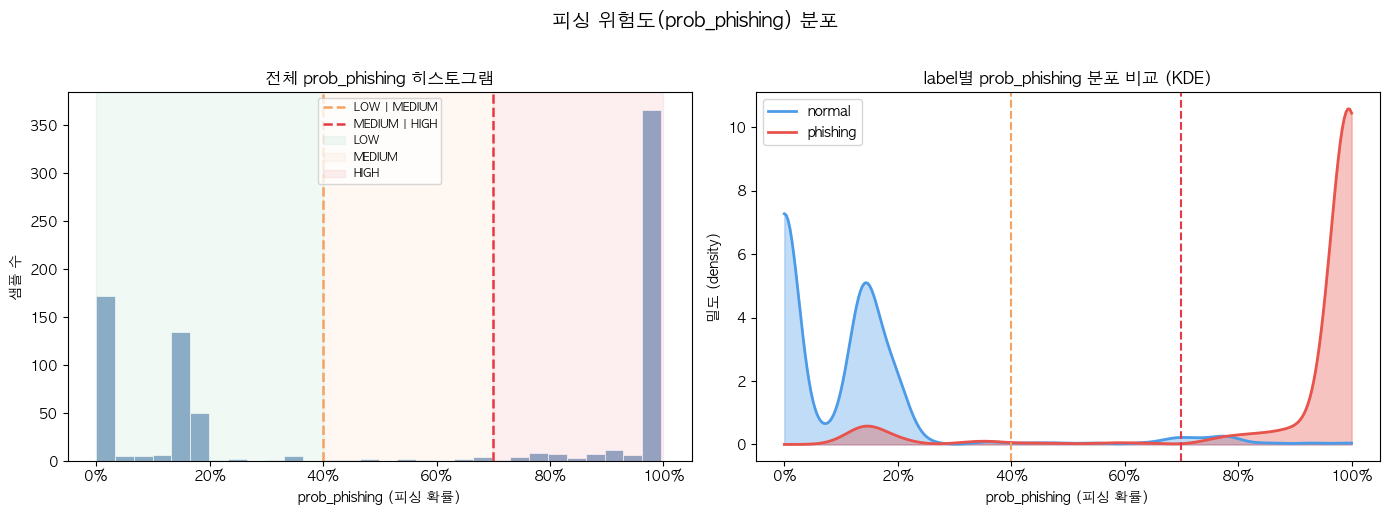

[Save] risk_distribution_fig1.png


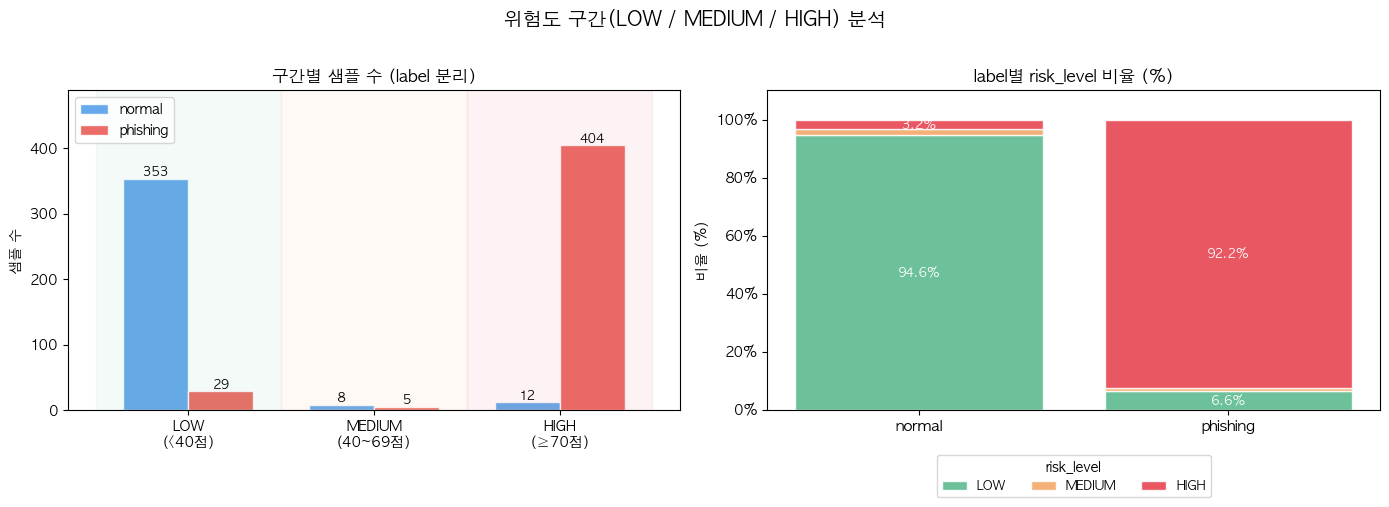

[Save] risk_distribution_fig2.png


In [3]:
"""
SafeFam — 피싱 탐지 모델 위험도 분포 시각화
=============================================
Jupyter Notebook 셀에서 실행.
사전 조건: train_v2.py 실행 완료 (phishing_model_artifact.pkl, phishing_vectorizer.pkl 존재)

차트 구성:
  Fig 1 - (1,2): prob_phishing 히스토그램 + KDE
  Fig 1 - (1,3): label별 prob_phishing 분포 비교 (KDE 오버레이)
  Fig 2 - (2,1): LOW / MEDIUM / HIGH 구간별 샘플 수 (label 색상 분리)
  Fig 2 - (2,2): label별 risk_level 비율 (stacked bar)
"""


# ── 의존성 ────────────────────────────────────────────────────────────────────
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix, hstack
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

# ── 상수 ──────────────────────────────────────────────────────────────────────
MODEL_PATH      = "phishing_model_artifact.pkl"
VECTORIZER_PATH = "phishing_vectorizer.pkl"
DATA_PATH       = "../Data/SMSData/phishing_total_dataset_2705.csv"
OUTPUT_FIG1     = "risk_distribution_fig1.png"   # 저장 경로
OUTPUT_FIG2     = "risk_distribution_fig2.png"

# risk_level 구간 경계
MEDIUM_LOWER = 0.40
HIGH_LOWER   = 0.70

# 색상 팔레트 (colorblind-friendly)
COLOR_NORMAL   = "#4C9BE8"   # 파랑 — 정상
COLOR_PHISHING = "#E8534C"   # 빨강 — 피싱
COLOR_LOW      = "#52B788"   # 초록
COLOR_MEDIUM   = "#F4A261"   # 주황
COLOR_HIGH     = "#E63946"   # 빨강

# ── 정규화 패턴 ───────────────────────────────────────────────────────────────
_RE_URL       = re.compile(r"https?://\S+|[a-zA-Z0-9.-]+\.(kr|com|net|cyou|xyz|me|io|cc)\S*")
_RE_PHONE     = re.compile(r"\d{2,4}-\d{3,4}-\d{4}")
_RE_LONG_NUM  = re.compile(r"\b\d{6,}\b")
_RE_AMOUNT    = re.compile(r"\d+[,\d]*원")
_RE_SHORT_URL = re.compile(r"bit\.ly|goo\.gl|tinyurl|gourl|ow\.ly|n\.bnuee|han\.gl|cutt\.ly")
_RE_WEB_TAG   = re.compile(r"\[Web발신\]|\[국외발신\]|\[국제발신\]")


# ── 데이터 준비 ───────────────────────────────────────────────────────────────

def _normalize_text(text: str) -> str:
    """가변 식별값을 일반화 토큰으로 치환."""
    text = _RE_URL.sub("<URL>", text)
    text = _RE_PHONE.sub("<전화번호>", text)
    text = _RE_LONG_NUM.sub("<긴숫자>", text)
    text = _RE_AMOUNT.sub("<금액>", text)
    return text.strip()


def _extract_struct(text: str) -> np.ndarray:
    """단일 샘플 구조적 피처 추출 (shape: 1 × 6)."""
    return np.array([[
        int(bool(_RE_URL.search(text))),
        int(bool(_RE_SHORT_URL.search(text))),
        int(bool(_RE_PHONE.search(text))),
        int(bool(_RE_AMOUNT.search(text))),
        int(bool(_RE_WEB_TAG.search(text))),
        int(len(text) > 100),
    ]])


def load_and_score(
    data_path: str,
    model_path: str,
    vectorizer_path: str,
) -> pd.DataFrame:
    """
    데이터 로드 → 중복 제거 → 모델 추론 → prob_phishing / risk_score / risk_level 컬럼 추가.

    Returns:
        DataFrame with columns: text, label, type, prob_phishing, risk_score, risk_level
    """
    # 아티팩트 로드
    artifact   = joblib.load(model_path)
    vectorizer = joblib.load(vectorizer_path)
    model      = artifact["model"]
    classes    = artifact["classes"]
    phish_idx  = classes.index("phishing")

    # 데이터 로드 + 정규화 + 중복 제거
    df = pd.read_csv(data_path)
    df["text_norm"] = df["text"].apply(_normalize_text)
    df = df.drop_duplicates(subset="text_norm").reset_index(drop=True)

    # 배치 추론 — 각 샘플별로 prob_phishing 계산
    probs: list[float] = []
    for _, row in df.iterrows():
        X = hstack([
            vectorizer.transform(pd.Series([row["text_norm"]])),
            csr_matrix(_extract_struct(row["text"])),
        ])
        probs.append(model.predict_proba(X)[0][phish_idx])

    # 점수 및 레벨 컬럼 추가
    df["prob_phishing"] = probs
    df["risk_score"]    = (df["prob_phishing"] * 100).astype(int)
    df["risk_level"]    = pd.cut(
        df["risk_score"],
        bins=[-1, 39, 69, 100],
        labels=["LOW", "MEDIUM", "HIGH"],
    )

    print(f"[Score] 완료: {len(df)}건 | label={df['label'].value_counts().to_dict()}")
    return df


# ── 차트 1: 히스토그램 + label별 KDE 비교 ──────────────────────────────────

def plot_distribution(df: pd.DataFrame, save_path: str) -> None:
    """
    Fig 1 — 두 개 차트:
      (좌) 전체 prob_phishing 히스토그램 + 구간 경계선
      (우) label별 KDE 오버레이 (phishing vs normal)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("피싱 위험도(prob_phishing) 분포", fontsize=14, fontweight="bold", y=1.02)

    probs_all      = df["prob_phishing"].values
    probs_phishing = df.loc[df["label"] == "phishing", "prob_phishing"].values
    probs_normal   = df.loc[df["label"] == "normal",   "prob_phishing"].values

    # ── 좌: 전체 히스토그램 ──────────────────────────────────────────────────
    ax = axes[0]
    ax.hist(probs_all, bins=30, color="#7B9EC1", edgecolor="white", linewidth=0.6, alpha=0.85)

    # 구간 경계선
    for x, label, color in [
        (MEDIUM_LOWER, "LOW | MEDIUM", COLOR_MEDIUM),
        (HIGH_LOWER,   "MEDIUM | HIGH", COLOR_HIGH),
    ]:
        ax.axvline(x, color=color, linewidth=1.8, linestyle="--", label=label)

    # 구간 배경 색칠
    ymax = ax.get_ylim()[1]
    ax.axvspan(0,             MEDIUM_LOWER, alpha=0.08, color=COLOR_LOW,    label="LOW")
    ax.axvspan(MEDIUM_LOWER,  HIGH_LOWER,   alpha=0.08, color=COLOR_MEDIUM, label="MEDIUM")
    ax.axvspan(HIGH_LOWER,    1.0,          alpha=0.08, color=COLOR_HIGH,   label="HIGH")

    ax.set_title("전체 prob_phishing 히스토그램", fontsize=12)
    ax.set_xlabel("prob_phishing (피싱 확률)")
    ax.set_ylabel("샘플 수")
    ax.legend(fontsize=8, loc="upper center")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    # ── 우: label별 KDE 오버레이 ─────────────────────────────────────────────
    ax2 = axes[1]
    for probs, label, color in [
        (probs_normal,   "normal",   COLOR_NORMAL),
        (probs_phishing, "phishing", COLOR_PHISHING),
    ]:
        # KDE 계산 (scipy gaussian_kde — seaborn 의존성 없이)
        kde    = gaussian_kde(probs, bw_method=0.15)
        x_grid = np.linspace(0, 1, 300)
        ax2.fill_between(x_grid, kde(x_grid), alpha=0.35, color=color)
        ax2.plot(x_grid, kde(x_grid), color=color, linewidth=2, label=label)

    # 구간 경계선
    for x, color in [(MEDIUM_LOWER, COLOR_MEDIUM), (HIGH_LOWER, COLOR_HIGH)]:
        ax2.axvline(x, color=color, linewidth=1.5, linestyle="--")

    ax2.set_title("label별 prob_phishing 분포 비교 (KDE)", fontsize=12)
    ax2.set_xlabel("prob_phishing (피싱 확률)")
    ax2.set_ylabel("밀도 (density)")
    ax2.legend(fontsize=10)
    ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Save] {save_path}")


# ── 차트 2: 구간별 샘플 수 + label별 비율 ──────────────────────────────────

def plot_level_breakdown(df: pd.DataFrame, save_path: str) -> None:
    """
    Fig 2 — 두 개 차트:
      (좌) LOW/MEDIUM/HIGH 구간별 샘플 수 (label 색상 분리 — grouped bar)
      (우) label별 risk_level 비율 (stacked bar 100%)
    """
    # 교차표 준비
    ct      = pd.crosstab(df["risk_level"], df["label"])           # shape: (3, 2)
    ct_pct  = ct.div(ct.sum(axis=1), axis=0) * 100                # 행 기준 비율

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("위험도 구간(LOW / MEDIUM / HIGH) 분석", fontsize=14, fontweight="bold", y=1.02)

    levels = ["LOW", "MEDIUM", "HIGH"]
    x      = np.arange(len(levels))
    width  = 0.35

    # ── 좌: grouped bar — 구간별 샘플 수 ─────────────────────────────────────
    ax = axes[0]
    bars_n = ax.bar(
        x - width / 2,
        [ct.loc[lv, "normal"]   if lv in ct.index else 0 for lv in levels],
        width, label="normal",   color=COLOR_NORMAL,   alpha=0.85, edgecolor="white",
    )
    bars_p = ax.bar(
        x + width / 2,
        [ct.loc[lv, "phishing"] if lv in ct.index else 0 for lv in levels],
        width, label="phishing", color=COLOR_PHISHING, alpha=0.85, edgecolor="white",
    )

    # 막대 위 수치 레이블
    for bar in [*bars_n, *bars_p]:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2, h + 1,
                str(int(h)), ha="center", va="bottom", fontsize=9,
            )

    # 구간 배경 색칠
    bg_colors = [COLOR_LOW, COLOR_MEDIUM, COLOR_HIGH]
    for i, (pos, color) in enumerate(zip(x, bg_colors)):
        ax.axvspan(pos - 0.5, pos + 0.5, alpha=0.06, color=color)

    ax.set_title("구간별 샘플 수 (label 분리)", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"LOW\n(<40점)", "MEDIUM\n(40~69점)", "HIGH\n(≥70점)"],
        fontsize=10,
    )
    ax.set_ylabel("샘플 수")
    ax.legend(fontsize=10)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

    # ── 우: stacked bar — label별 risk_level 비율 ────────────────────────────
    ax2   = axes[1]
    labels_order = ["normal", "phishing"]
    x2    = np.arange(len(labels_order))

    # 각 label에서 LOW/MEDIUM/HIGH 비율
    pct_by_label = pd.crosstab(df["label"], df["risk_level"], normalize="index") * 100
    for col in ["LOW", "MEDIUM", "HIGH"]:
        if col not in pct_by_label.columns:
            pct_by_label[col] = 0.0

    bottom = np.zeros(len(labels_order))
    for lv, color in [("LOW", COLOR_LOW), ("MEDIUM", COLOR_MEDIUM), ("HIGH", COLOR_HIGH)]:
        vals = [pct_by_label.loc[l, lv] if l in pct_by_label.index else 0 for l in labels_order]
        bars = ax2.bar(x2, vals, bottom=bottom, label=lv, color=color, alpha=0.85, edgecolor="white")

        # 비율 레이블 (3% 이상일 때만 표시)
        for i, (bar, val) in enumerate(zip(bars, vals)):
            if val >= 3:
                ax2.text(
                    bar.get_x() + bar.get_width() / 2,
                    bottom[i] + val / 2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=9, fontweight="bold", color="white",
                )
        bottom += np.array(vals)

    ax2.set_title("label별 risk_level 비율 (%)", fontsize=12)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(["normal", "phishing"], fontsize=11)
    ax2.set_ylabel("비율 (%)")
    ax2.set_ylim(0, 110)
    ax2.legend(
        title="risk_level", fontsize=9,
        loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3,
    )
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter())

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[Save] {save_path}")


# ── 콘솔 요약 출력 ────────────────────────────────────────────────────────────

def print_summary(df: pd.DataFrame) -> None:
    """구간별/label별 핵심 통계 요약 출력."""
    print("\n" + "=" * 50)
    print("[ 위험도 분포 요약 ]")
    print("=" * 50)

    ct = pd.crosstab(df["risk_level"], df["label"], margins=True)
    print(ct)

    print("\n[ label별 prob_phishing 통계 ]")
    print(df.groupby("label")["prob_phishing"].agg(["mean", "median", "std", "min", "max"]).round(4))

    print("\n[ 구간별 피싱 적중률 ]")
    for lv in ["LOW", "MEDIUM", "HIGH"]:
        sub = df[df["risk_level"] == lv]
        if len(sub) == 0:
            continue
        phish_rate = (sub["label"] == "phishing").mean() * 100
        print(f"  {lv:6}: {len(sub):3}건 | 피싱 비율 {phish_rate:.1f}%")


# ── 진입점 ───────────────────────────────────────────────────────────────────

# Jupyter에서 직접 실행하거나 아래 셀로 나눠서 사용 가능
df_scored = load_and_score(DATA_PATH, MODEL_PATH, VECTORIZER_PATH)

print_summary(df_scored)
plot_distribution(df_scored, OUTPUT_FIG1)
plot_level_breakdown(df_scored, OUTPUT_FIG2)

=== 피싱 판단 기여 상위 20 키워드 (log_prob 차이 기준) ===

   1. 'has_short_url'  (score=2.5684)
   2. '대출'  (score=2.2881)
   3. ' 장'  (score=2.1252)
   4. ' 엄마'  (score=2.1175)
   5. '당첨'  (score=2.1175)
   6. '엄마'  (score=2.1175)
   7. ' 당첨'  (score=2.1175)
   8. ' 장모'  (score=2.0699)
   9. ' 장모님'  (score=2.0699)
  10. '장모님'  (score=2.0699)
  11. '모님'  (score=2.0699)
  12. '장모'  (score=2.0699)
  13. ' 이체'  (score=2.0452)
  14. '좌번'  (score=1.9939)
  15. '좌번호'  (score=1.9939)
  16. '엄마 '  (score=1.9939)
  17. '계좌번'  (score=1.9939)
  18. '계좌번호'  (score=1.9939)
  19. ' 엄마 '  (score=1.9939)
  20. '수령'  (score=1.9806)

=== 정상 판단 기여 상위 20 키워드 ===

   1. '=='  (score=-3.9739)
   2. '==='  (score=-3.9261)
   3. '===='  (score=-3.8759)
   4. '주차'  (score=-2.2090)
   5. ' : '  (score=-2.1967)
   6. ' :'  (score=-2.1938)
   7. '쿠폰'  (score=-2.1827)
   8. '■ '  (score=-2.1384)
   9. ' ■ '  (score=-2.1384)
  10. ' 쿠폰'  (score=-2.1343)
  11. '- '  (score=-2.1292)
  12. ' 답'  (score=-2.1137)
  13. ' - '  (score

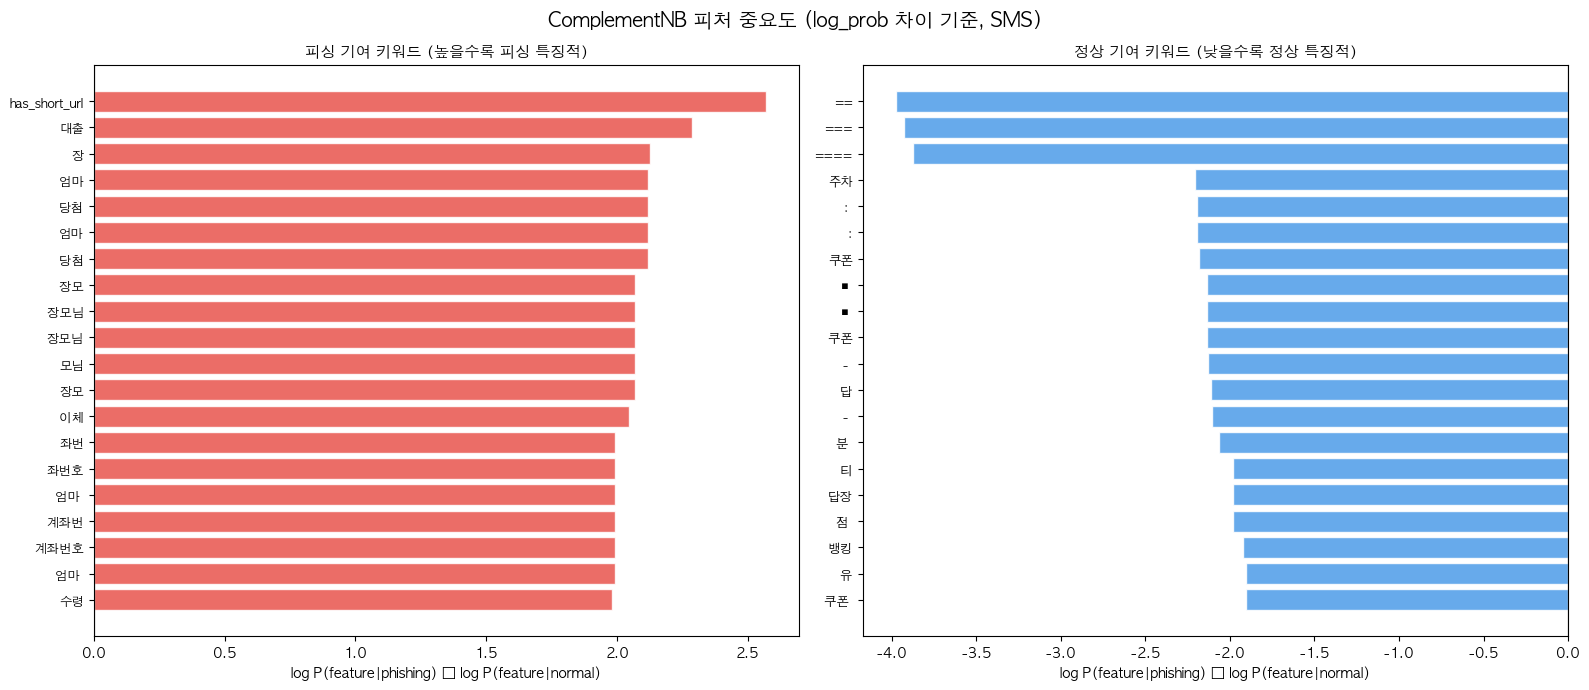

[Save] feature_importance.png


In [4]:
# ============================================================
# [검증 셀] 피처 중요도 분석 (SMS)
# ComplementNB는 LinearExplainer 미지원
# → feature_log_prob_ 기반 클래스별 피처 중요도로 대체
#   (phishing log_prob - normal log_prob = 해당 n-gram이 피싱에 얼마나 특징적인지)
# Voice 모델(VoiceData.ipynb 검증 셀 5/6)과 동일한 방식
# ============================================================

import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 경로 & 아티팩트 ──────────────────────────────────────────
MODEL_PATH      = Path("phishing_model_artifact.pkl")
VECTORIZER_PATH = Path("phishing_vectorizer.pkl")

artifact   = joblib.load(MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)
model      = artifact["model"]

# ── 피처명 구성 (텍스트 n-gram + 구조적 피처 6개) ──────────────
feature_names = list(vectorizer.get_feature_names_out()) + [
    "has_url", "has_short_url", "has_phone", "has_amount", "has_web_tag", "is_long_text",
]

# ── base_estimator 추출 ─────────────────────────────────────
# CalibratedClassifierCV → 내부 calibrated_classifiers_[0].estimator
base_nb = model.calibrated_classifiers_[0].estimator
# ComplementNB.feature_log_prob_: shape (n_classes, n_features)
# classes_ 순서: ['normal', 'phishing']
normal_idx_nb   = list(base_nb.classes_).index("normal")
phishing_idx_nb = list(base_nb.classes_).index("phishing")

# 구조적 피처 6개는 ComplementNB 학습에 포함됐으므로
# feature_log_prob_ 열 수 = 텍스트 피처 수 + 6
log_prob_normal   = base_nb.feature_log_prob_[normal_idx_nb]
log_prob_phishing = base_nb.feature_log_prob_[phishing_idx_nb]

# 피싱 특징도 = P(feature|phishing) - P(feature|normal) 로그 차이
# 값이 클수록 피싱에서 더 자주 등장하는 패턴
phishing_score = log_prob_phishing - log_prob_normal

# ── 상위/하위 20개 추출 ──────────────────────────────────────
n_top = 20
top_phishing_idx = np.argsort(phishing_score)[::-1][:n_top]  # 피싱 기여
top_normal_idx   = np.argsort(phishing_score)[:n_top]         # 정상 기여

print("=== 피싱 판단 기여 상위 20 키워드 (log_prob 차이 기준) ===\n")
for rank, idx in enumerate(top_phishing_idx, 1):
    print(f"  {rank:2}. '{feature_names[idx]}'  (score={phishing_score[idx]:.4f})")

print("\n=== 정상 판단 기여 상위 20 키워드 ===\n")
for rank, idx in enumerate(top_normal_idx, 1):
    print(f"  {rank:2}. '{feature_names[idx]}'  (score={phishing_score[idx]:.4f})")

# ── 시각화 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("ComplementNB 피처 중요도 (log_prob 차이 기준, SMS)", fontsize=14, fontweight="bold")

# 피싱 기여 키워드
p_names  = [feature_names[i] for i in top_phishing_idx]
p_scores = [phishing_score[i] for i in top_phishing_idx]
axes[0].barh(range(n_top), p_scores[::-1], color="#E8534C", alpha=0.85, edgecolor="white")
axes[0].set_yticks(range(n_top))
axes[0].set_yticklabels(p_names[::-1], fontsize=9)
axes[0].set_title("피싱 기여 키워드 (높을수록 피싱 특징적)", fontsize=11)
axes[0].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[0].axvline(0, color="black", linewidth=0.8)

# 정상 기여 키워드
n_names  = [feature_names[i] for i in top_normal_idx]
n_scores = [phishing_score[i] for i in top_normal_idx]
axes[1].barh(range(n_top), n_scores[::-1], color="#4C9BE8", alpha=0.85, edgecolor="white")
axes[1].set_yticks(range(n_top))
axes[1].set_yticklabels(n_names[::-1], fontsize=9)
axes[1].set_title("정상 기여 키워드 (낮을수록 정상 특징적)", fontsize=11)
axes[1].set_xlabel("log P(feature|phishing) − log P(feature|normal)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("[Save] feature_importance.png")


In [5]:
# ============================================================
# [검증 셀] 전체 피처 점수 목록 (SMS, 생략 없이 전체 출력)
#
# 검증 셀(피처 중요도)은 상/하위 20개만 보여주는데, 여기서는
# 학습된 8,000+6개 피처 전체를 phishing_score 내림차순으로
# 하나도 생략하지 않고 출력하고 CSV로도 저장한다.
# ============================================================

import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

MODEL_PATH      = Path("phishing_model_artifact.pkl")
VECTORIZER_PATH = Path("phishing_vectorizer.pkl")

artifact   = joblib.load(MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)
model      = artifact["model"]

feature_names = list(vectorizer.get_feature_names_out()) + [
    "has_url", "has_short_url", "has_phone", "has_amount", "has_web_tag", "is_long_text",
]

base_nb = model.calibrated_classifiers_[0].estimator
normal_idx_nb   = list(base_nb.classes_).index("normal")
phishing_idx_nb = list(base_nb.classes_).index("phishing")
log_prob_normal   = base_nb.feature_log_prob_[normal_idx_nb]
log_prob_phishing = base_nb.feature_log_prob_[phishing_idx_nb]
phishing_score    = log_prob_phishing - log_prob_normal

df_features = pd.DataFrame({
    "feature": feature_names,
    "phishing_score": phishing_score,
    "log_prob_phishing": log_prob_phishing,
    "log_prob_normal": log_prob_normal,
}).sort_values("phishing_score", ascending=False).reset_index(drop=True)

# ── 출력 옵션: 행/열 생략("...") 없이 전체 표시 ─────────────────
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

print(f"=== [SMS] 전체 피처 {len(df_features)}개 — phishing_score 내림차순, 생략 없음 ===\n")
print(df_features.to_string(index=True))

SAVE_PATH = "feature_scores_full.csv"
df_features.to_csv(SAVE_PATH, index=False, encoding="utf-8-sig")
print(f"\n[Save] {SAVE_PATH} — 전체 {len(df_features)}개 피처")


=== [SMS] 전체 피처 8006개 — phishing_score 내림차순, 생략 없음 ===

            feature  phishing_score  log_prob_phishing  log_prob_normal
0     has_short_url        2.568413           9.646733         7.078321
1                대출        2.288111           9.829055         7.540944
2                 장        2.125207           9.646733         7.521526
3                당첨        2.117485           9.829055         7.711570
4                엄마        2.117485           9.829055         7.711570
5                당첨        2.117485           9.829055         7.711570
6                엄마        2.117485           9.829055         7.711570
7                모님        2.069857           9.829055         7.759198
8                장모        2.069857           9.829055         7.759198
9               장모님        2.069857           9.829055         7.759198
10               장모        2.069857           9.829055         7.759198
11              장모님        2.069857           9.829055         7.759198
12      

=== [SMS] 피싱 근거 피처 클러스터 ===

[클러스터 0] 평균 score=+2.186, 6개
  has_short_url, 대출, 당첨,  당첨,  이체, 수령

[클러스터 1] 평균 score=+2.006, 20개
   장,  장모,  장모님, 장모님, 모님, 장모, 좌번, 좌번호, 계좌번, 계좌번호, 좌번호),  (계좌,  (계, 번호) , (계좌번, 호) , 호), (계좌, (계, 번호)

[클러스터 2] 평균 score=+2.056, 4개
   엄마, 엄마, 엄마 ,  엄마 

=== [SMS] 정상 근거 피처 클러스터 ===

[클러스터 0] 평균 score=-2.336, 18개
  ==, ===, ====, 쿠폰, ■ ,  ■ ,  쿠폰, - ,  답,  - , 답장, 점 , 쿠폰 , 음 , )로 ,  있음, 있음, )로

[클러스터 1] 평균 score=-1.859, 7개
   티,  유, 머니, 티머, 머니 ,  티머, 티머니

[클러스터 2] 평균 score=-2.117, 5개
  주차,  : ,  :, 분 , 뱅킹



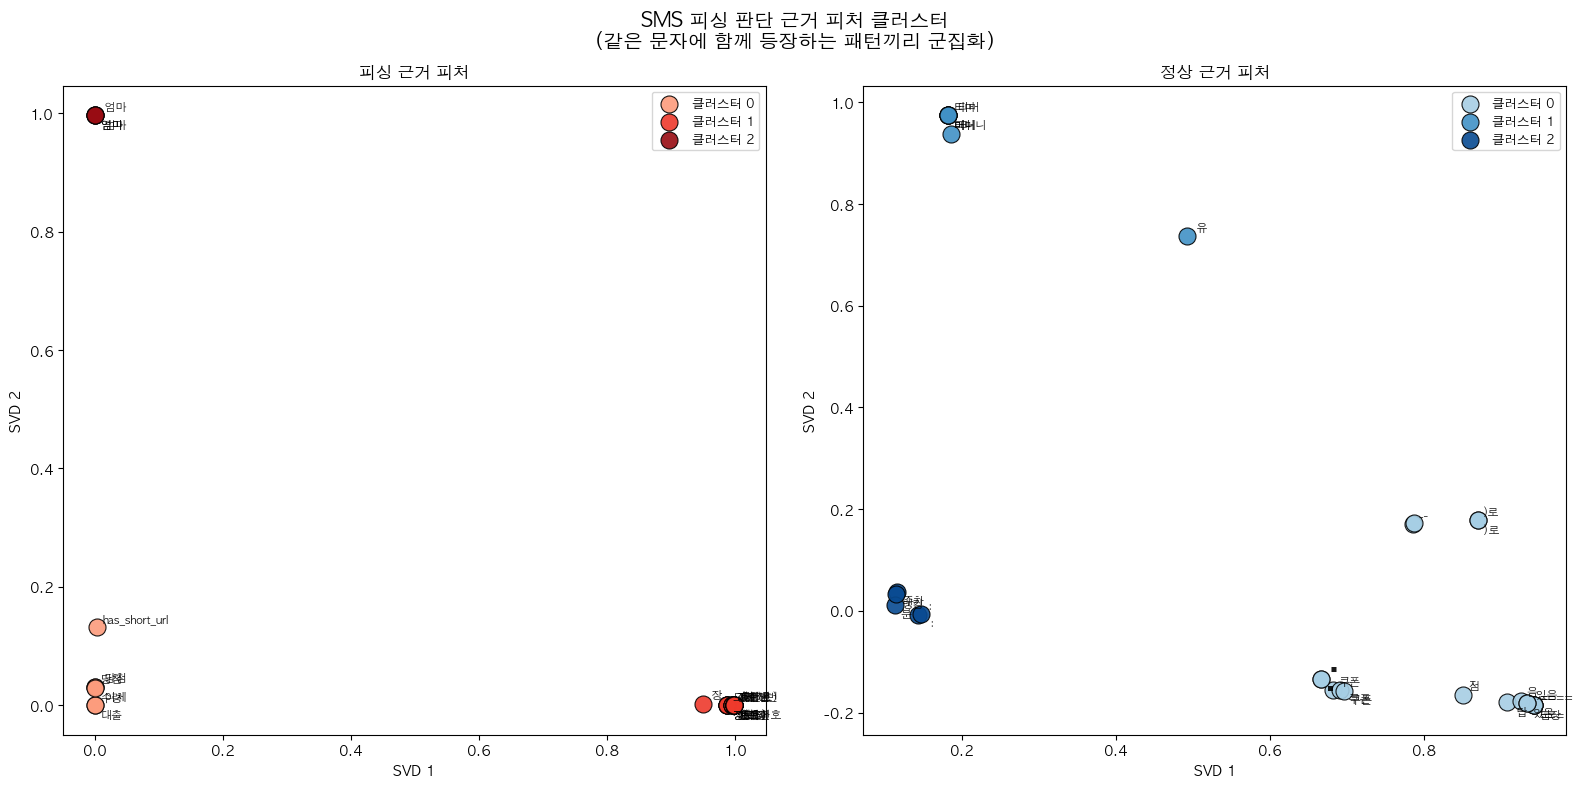


[Save] feature_clusters.png


In [6]:
# ============================================================
# [검증 셀] 피싱 / 정상 근거 피처 클러스터링 (SMS)
#
# 목적: 개별 키워드 중요도(로그확률 차이)를 넘어,
#       "어떤 키워드들이 실제로 같은 문자 안에서 함께 등장해
#        하나의 근거 테마를 이루는가"를 클러스터로 확인.
#       예) '엄마' '계좌번호' 가 같은 클러스터(가족 사칭 송금 유도)로 묶이는지
#
# 방법:
#   1) ComplementNB feature_log_prob_ 차이로 피싱/정상 근거 상위 피처 선정
#   2) 각 피처를 "그 피처가 등장한 학습 문서 벡터"로 표현
#      (같은 문자에 자주 함께 등장하는 피처일수록 벡터가 유사해짐)
#   3) 피싱 근거 / 정상 근거를 각각 독립적으로 KMeans + TruncatedSVD(2D)
#      → 두 그룹을 한 축에 섞으면 "피싱이냐 정상이냐" 차이가 다른 모든 변동을
#        압도해버려 클러스터 구조가 안 보이므로 패널을 분리
#
# 주의: train_v2.py와 동일한 RANDOM_STATE/VAL_SIZE/TEST_SIZE로
#       train split을 그대로 재현 — 근거 클러스터링도 train에만 기반
# ============================================================

import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack, csr_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import normalize

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 경로 & 아티팩트 ──────────────────────────────────────────
MODEL_PATH      = Path("phishing_model_artifact.pkl")
VECTORIZER_PATH = Path("phishing_vectorizer.pkl")
DATA_PATH       = Path("../Data/SMSData/phishing_total_dataset_2705.csv")

RANDOM_STATE = 42
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

artifact   = joblib.load(MODEL_PATH)
vectorizer = joblib.load(VECTORIZER_PATH)
model      = artifact["model"]

# ── 정규화 / 구조적 피처 (train_v2.py와 동일 정의) ────────────
_RE_URL       = re.compile(r"https?://\S+|[a-zA-Z0-9.-]+\.(kr|com|net|cyou|xyz|me|io|cc)\S*")
_RE_PHONE     = re.compile(r"\d{2,4}-\d{3,4}-\d{4}")
_RE_LONG_NUM  = re.compile(r"\b\d{6,}\b")
_RE_AMOUNT    = re.compile(r"\d+[,\d]*원")
_RE_SHORT_URL = re.compile(r"bit\.ly|goo\.gl|tinyurl|gourl|ow\.ly|n\.bnuee|han\.gl|cutt\.ly")
_RE_WEB_TAG   = re.compile(r"\[Web발신\]|\[국외발신\]|\[국제발신\]")

STRUCT_NAMES = [
    "has_url", "has_short_url", "has_phone", "has_amount", "has_web_tag", "is_long_text",
]

def _normalize_text(text: str) -> str:
    text = _RE_URL.sub("<URL>", text)
    text = _RE_PHONE.sub("<전화번호>", text)
    text = _RE_LONG_NUM.sub("<긴숫자>", text)
    text = _RE_AMOUNT.sub("<금액>", text)
    return text.strip()

def _extract_struct_features(texts: pd.Series, has_url: pd.Series) -> np.ndarray:
    return np.column_stack([
        has_url.astype(int).values,
        texts.str.contains(_RE_SHORT_URL).astype(int).values,
        texts.str.contains(_RE_PHONE).astype(int).values,
        texts.str.contains(_RE_AMOUNT).astype(int).values,
        texts.str.contains(_RE_WEB_TAG).astype(int).values,
        (texts.str.len() > 100).astype(int).values,
    ])

# ── 데이터 로드 + dedup + train split 복원 (train_v2.py와 동일 절차) ─
df = pd.read_csv(DATA_PATH)
df["text_norm"] = df["text"].apply(_normalize_text)
df = df.drop_duplicates(subset="text_norm").reset_index(drop=True)

sss_test = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
trainval_idx, _ = next(sss_test.split(df, df["label"]))
df_trainval = df.iloc[trainval_idx].reset_index(drop=True)

val_ratio = VAL_SIZE / (1 - TEST_SIZE)
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=RANDOM_STATE)
train_idx, _ = next(sss_val.split(df_trainval, df_trainval["label"]))
df_train = df_trainval.iloc[train_idx].reset_index(drop=True)

struct_train = _extract_struct_features(df_train["text"], df_train["has_url"])
X_text_train = vectorizer.transform(df_train["text_norm"])
X_train       = hstack([X_text_train, csr_matrix(struct_train)]).tocsr()

feature_names = list(vectorizer.get_feature_names_out()) + STRUCT_NAMES

# ── 피싱 특징도 (log_prob 차이) ───────────────────────────────
base_nb = model.calibrated_classifiers_[0].estimator
normal_idx_nb   = list(base_nb.classes_).index("normal")
phishing_idx_nb = list(base_nb.classes_).index("phishing")
phishing_score  = base_nb.feature_log_prob_[phishing_idx_nb] - base_nb.feature_log_prob_[normal_idx_nb]

N_TOP = 30
top_phishing_idx = np.argsort(phishing_score)[::-1][:N_TOP]   # 피싱 근거 상위
top_normal_idx   = np.argsort(phishing_score)[:N_TOP]         # 정상 근거 상위


def cluster_side(idx_list, n_clusters):
    """선택된 피처 idx들을 '문서 등장 벡터' 기준으로 클러스터링 + 2D 투영."""
    vecs = normalize(X_train[:, idx_list].T)  # (N_TOP, n_train_docs)
    km   = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(vecs)
    coords = TruncatedSVD(n_components=2, random_state=42).fit_transform(vecs)
    return labels, coords


N_CLUSTERS = 3
labels_p, coords_p = cluster_side(top_phishing_idx, N_CLUSTERS)
labels_n, coords_n = cluster_side(top_normal_idx, N_CLUSTERS)


def print_clusters(title, idx_list, labels, n_clusters):
    print(f"=== {title} ===\n")
    for c in range(n_clusters):
        members = np.where(labels == c)[0]
        names  = [feature_names[idx_list[i]] for i in members]
        scores = [phishing_score[idx_list[i]] for i in members]
        print(f"[클러스터 {c}] 평균 score={np.mean(scores):+.3f}, {len(members)}개")
        print(f"  {', '.join(names)}\n")


print_clusters("[SMS] 피싱 근거 피처 클러스터", top_phishing_idx, labels_p, N_CLUSTERS)
print_clusters("[SMS] 정상 근거 피처 클러스터", top_normal_idx, labels_n, N_CLUSTERS)

# ── 시각화 (좌: 피싱 근거 / 우: 정상 근거, 패널별 독립 축) ──────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(
    "SMS 피싱 판단 근거 피처 클러스터\n(같은 문자에 함께 등장하는 패턴끼리 군집화)",
    fontsize=14, fontweight="bold",
)

for ax, idx_list, labels, color, title in [
    (axes[0], top_phishing_idx, labels_p, plt.get_cmap("Reds"),  "피싱 근거 피처"),
    (axes[1], top_normal_idx,   labels_n, plt.get_cmap("Blues"), "정상 근거 피처"),
]:
    coords = coords_p if idx_list is top_phishing_idx else coords_n
    for c in range(N_CLUSTERS):
        mask = labels == c
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            s=150, color=color(0.35 + 0.55 * c / max(N_CLUSTERS - 1, 1)),
            edgecolor="black", linewidth=0.8, alpha=0.9, label=f"클러스터 {c}",
        )
    for i, idx in enumerate(idx_list):
        ax.annotate(
            feature_names[idx], (coords[i, 0], coords[i, 1]),
            fontsize=8, alpha=0.9, xytext=(4, 4 if i % 2 == 0 else -9),
            textcoords="offset points",
        )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("SVD 1")
    ax.set_ylabel("SVD 2")
    ax.legend(fontsize=9, loc="best")

plt.tight_layout()
plt.savefig("feature_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[Save] feature_clusters.png")
